In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits

### Load and examine SST data

Keep in mind now it has time-coordinate too. 

In [2]:
import os

In [3]:
test = fits.open('/mnt/c/Users/ivanz/OneDrive/Data/Ivan_Rahul_data_exchange/nb_8542_2019-05-06T08_33_15_scans=0-170_stokes_corrected_ALIGNED_sp_2pix_binned.fits')

In [4]:
test.info()

Filename: /mnt/c/Users/ivanz/OneDrive/Data/Ivan_Rahul_data_exchange/nb_8542_2019-05-06T08_33_15_scans=0-170_stokes_corrected_ALIGNED_sp_2pix_binned.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   (17, 4, 558, 535, 171)   float64   


In [8]:
cube_test = np.copy(test[0].data[0,:,:,0,:])

In [9]:
cube_test.shape

(535, 558, 17)

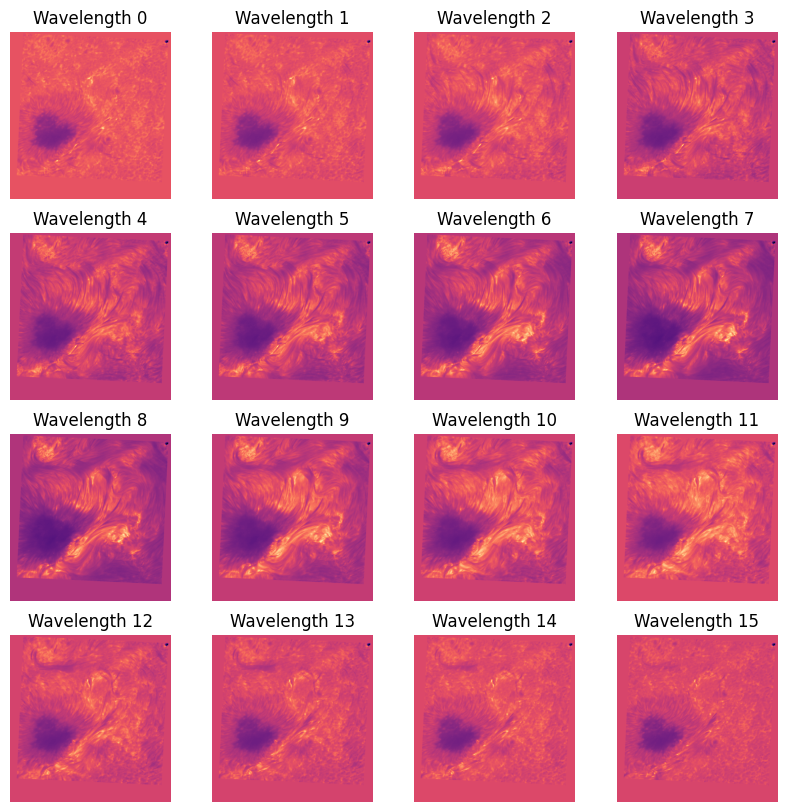

In [11]:
# Plot first 16 wavelenghts in a 4x4 grid: 

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(cube_test[:,:,i].T, origin='lower', cmap='magma')
    plt.title(f'Wavelength {i}')
    plt.axis('off')


In [12]:
# Create mini-version of Hinode data

stokesph = fits.open('~/data/espd_school/sp3d_25012017_corrected.fits')[0].data

In [13]:
stokesph.shape

(512, 870, 4, 112)

In [18]:
stokesmini = stokesph[100:-100:2,200:-1:2,:,:50]

In [19]:
stokesmini.shape

(156, 335, 4, 50)

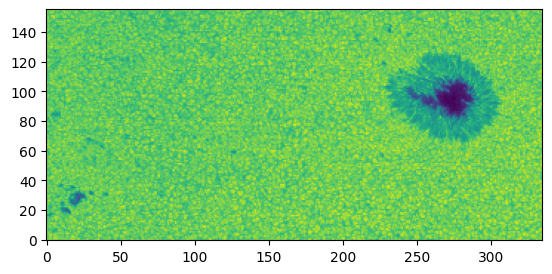

In [21]:
plt.imshow(stokesmini[:,:,0,0], origin='lower')

In [22]:
kek = fits.PrimaryHDU(stokesmini)

In [23]:
kek.writeto('sp3d_25012017_corrected_mini.fits', overwrite=True)